***1. TRAIN DEEP NEURAL NETWORK MODEL WITH FIXED LEARNING RATE***

c:\Users\prneh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5877 - loss: 1.5311 - val_accuracy: 0.8141 - val_loss: 0.7250
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8469 - loss: 0.5700 - val_accuracy: 0.8814 - val_loss: 0.4293
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8859 - loss: 0.4099 - val_accuracy: 0.8988 - val_loss: 0.3534
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9011 - loss: 0.3505 - val_accuracy: 0.9076 - val_loss: 0.3134
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9103 - loss: 0.3164 - val_accuracy: 0.9171 - val_loss: 0.2874
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9173 - loss: 0.2919 - val_accuracy: 0.9233 - val_loss: 0.2684
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9227 - loss: 0.2729 - val_accuracy: 0.9258 - val_loss: 0.2545
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9275 - loss: 0.2567 - val_accuracy: 0.

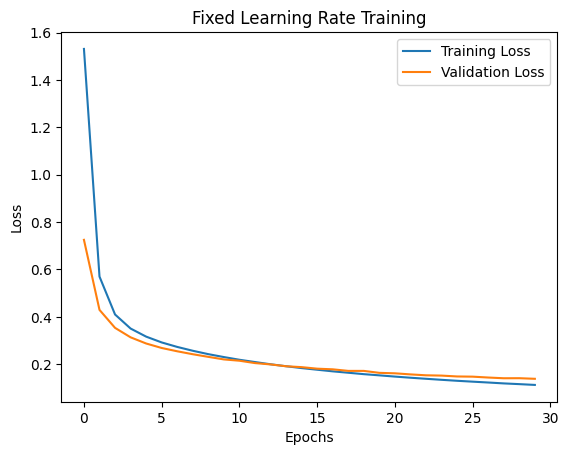

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# -----------------------------
# Load MNIST Dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build Deep Neural Network
# -----------------------------
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# -----------------------------
# Fixed Learning Rate Optimizer
# -----------------------------
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Train the Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# Plot Loss Curve
# -----------------------------
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Fixed Learning Rate Training')
plt.show()


***2. APPLY LEARNING RATE DECAY STRATEGIES***

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5162 - loss: 1.7053 - val_accuracy: 0.8166 - val_loss: 0.8542 - learning_rate: 0.0100
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8481 - loss: 0.6031 - val_accuracy: 0.8870 - val_loss: 0.4316 - learning_rate: 0.0100
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8863 - loss: 0.4116 - val_accuracy: 0.9019 - val_loss: 0.3481 - learning_rate: 0.0100
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9006 - loss: 0.3512 - val_accuracy: 0.9125 - val_loss: 0.3103 - learning_rate: 0.0100
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9089 - loss: 0.3168 - val_accuracy: 0.9194 - val_loss: 0.2842 - learning_rate: 0.0100
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9150 - loss: 0.2925 - val_accuracy: 0.9238 - val_loss: 0.2696 - learning_rate: 0.0100
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9215 - loss: 0.2730 - 

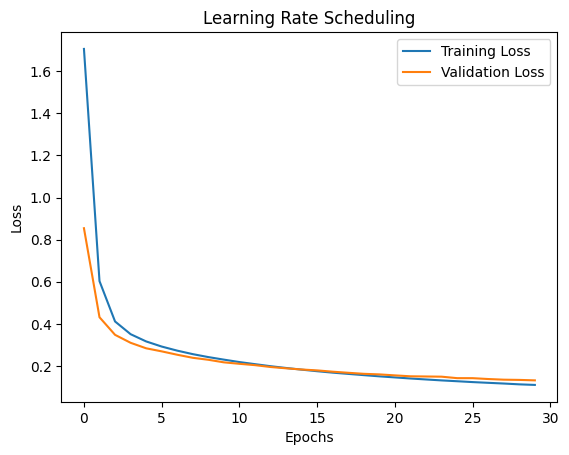

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau

# -----------------------------
# Load MNIST Dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build Deep Neural Network
# -----------------------------
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# -----------------------------
# Optimizer with Initial LR
# -----------------------------
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Learning Rate Scheduler
# -----------------------------
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

# -----------------------------
# Train the Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[lr_scheduler],
    verbose=1
)

# -----------------------------
# Plot Loss Curve
# -----------------------------
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Learning Rate Scheduling')
plt.show()


***3. ENABLE EARLY STOPPING***

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6184 - loss: 1.4719 - val_accuracy: 0.8429 - val_loss: 0.6650 - learning_rate: 0.0100
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8594 - loss: 0.5298 - val_accuracy: 0.8892 - val_loss: 0.4072 - learning_rate: 0.0100
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8908 - loss: 0.3937 - val_accuracy: 0.9030 - val_loss: 0.3413 - learning_rate: 0.0100
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9035 - loss: 0.3426 - val_accuracy: 0.9124 - val_loss: 0.3068 - learning_rate: 0.0100
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9117 - loss: 0.3114 - val_accuracy: 0.9193 - val_loss: 0.2822 - learning_rate: 0.0100
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9172 - loss: 0.2877 - val_accuracy: 0.9220 - val_loss: 0.2661 - learning_rate: 0.0100
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9239 - loss: 0.2682 - 

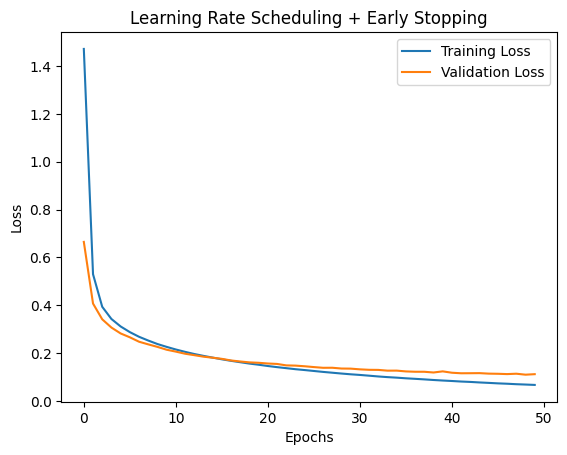

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# -----------------------------
# Load MNIST Dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build Deep Neural Network
# -----------------------------
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# -----------------------------
# Optimizer
# -----------------------------
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Callbacks
# -----------------------------
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=50,  # large number, early stopping will stop it
    batch_size=128,
    validation_split=0.2,
    callbacks=[lr_scheduler, early_stopping],
    verbose=1
)

# -----------------------------
# Plot Loss Curve
# -----------------------------
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Learning Rate Scheduling + Early Stopping')
plt.show()
